# 随机变量与常见分布

学习目标：把随机结果表示成随机变量，区分质量、密度和累计概率，按参数与生成条件选择常见分布，并核对归一化、区间概率和分位数。

前置知识：样本空间、概率、独立性、有限求和、定积分；Python 函数和 NumPy 数组。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11；只使用本地教学模拟，无外部数据。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 随机变量是从结果到数值的映射

掷一枚公平六面骰子，样本空间为 $\Omega=\{1,2,3,4,5,6\}$。约定点数为 1、2、3 时记分为 0，点数为 4、5 时记分为 1，点数为 6 时记分为 2。这个记分规则就是一个随机变量 X。

一般写成 $X:\Omega\to\mathbb R$：每个结果 $\omega\in\Omega$ 对应一个实数 $X(\omega)$。大写 X 表示映射，小写 x 表示可能取到的数值；一次实验观察到的数是 X 的一个实现值。

事件 X=1 包含骰子点数 4 和 5，所以 $P(X=1)=2/6$。不同结果可以映射为同一个数，需要把这些结果的概率相加。

In [1]:
from math import comb

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.integrate import quad

outcomes = np.arange(1, 7)
scores = np.array([0, 0, 0, 1, 1, 2])
print("骰子点数：", outcomes)  # 预期为 [1 2 3 4 5 6]。
print("对应记分：", scores)  # 预期为 [0 0 0 1 1 2]。
print("X=1 对应的结果：", outcomes[scores == 1])  # [4, 5]。
print("P(X=1)：", np.count_nonzero(scores == 1) / outcomes.size)  # 1/3。

骰子点数： [1 2 3 4 5 6]
对应记分： [0 0 0 1 1 2]
X=1 对应的结果： [4 5]
P(X=1)： 0.3333333333333333


## 2 离散分布用概率质量函数表示

若 X 只在有限个或可数个值上取值，它是离散随机变量（discrete random variable）。概率质量函数（probability mass function，PMF）定义为 $p_X(x)=P(X=x)$，满足

$$p_X(x)\ge0,\qquad \sum_x p_X(x)=1.$$

求和覆盖所有可能取值；取不到的值可令质量为零。本章把正概率取值的集合称为离散分布的支持集。记分例子的支持集为 {0,1,2}，质量依次为 $1/2,1/3,1/6$，并不是均匀分布。

计算 $P(X\ge1)$ 时，应加上 x=1 和 x=2 的质量，而不是对 x=1、2 这两个数取平均。

In [2]:
support = np.array([0, 1, 2])
probabilities = np.array([np.count_nonzero(scores == value) / 6 for value in support])
# 预期约为 [(0, 0.5), (1, 0.333333), (2, 0.166667)]。
print("可能取值与质量：", list(zip(support.tolist(), probabilities.tolist())))
print("非负且总和为 1：", np.all(probabilities >= 0), probabilities.sum())  # 非负判断为 True，概率总和约为 1。
print("P(X≥1)：", probabilities[support >= 1].sum())  # 1/2。
print("P(X=0.5)：", 0.0)  # 0.5 不在本例的支持集中。

可能取值与质量： [(0, 0.5), (1, 0.3333333333333333), (2, 0.16666666666666666)]
非负且总和为 1： True 0.9999999999999999
P(X≥1)： 0.5
P(X=0.5)： 0.0


## 3 分布函数累计的是不大于阈值的概率

累计分布函数（cumulative distribution function，CDF）对每个实数 t 定义为

$$F_X(t)=P(X\le t).$$

它对离散和连续模型都适用；取值在 [0,1] 内，随 t 非递减，t 趋于负无穷与正无穷时分别趋于 0 与 1。

记分例子中，$F_X(t)$ 在 t<0 时为 0，在 $0\le t<1$ 时为 1/2，在 $1\le t<2$ 时为 5/6，在 t≥2 时为 1。跳跃点处包含该点的质量；因此必须分清 ≤ 和 <。

对 a<b，有 $P(a<X\le b)=F_X(b)-F_X(a)$。若两端都包含，对本例应直接加对应质量，不能仍然减去包含 a 本身的 $F_X(a)$。

In [3]:
def score_cdf(threshold):
    return probabilities[support <= threshold].sum()


for threshold in (-0.1, 0.0, 0.5, 1.0, 1.5, 2.0):
    print(f"F({threshold:.1f})={score_cdf(threshold):.6f}")  # 按给定阈值顺序，CDF 为 0、1/2、1/2、5/6、5/6、1。
print("P(0<X≤1)：", score_cdf(1) - score_cdf(0))  # 1/3。
print("P(0≤X≤1)：", probabilities[support <= 1].sum())  # 5/6。

F(-0.1)=0.000000
F(0.0)=0.500000
F(0.5)=0.500000
F(1.0)=0.833333
F(1.5)=0.833333
F(2.0)=1.000000
P(0<X≤1)： 0.33333333333333326
P(0≤X≤1)： 0.8333333333333333


### 3.1 将 PMF 与 CDF 放在一起看

左图柱高表示每个取值的概率，柱宽只为展示，不参与概率计算。右图的水平线段表示累计概率，实心点是该处的函数值，空心点表示不取到的左侧高度。阶梯跳跃的高度等于对应 PMF。

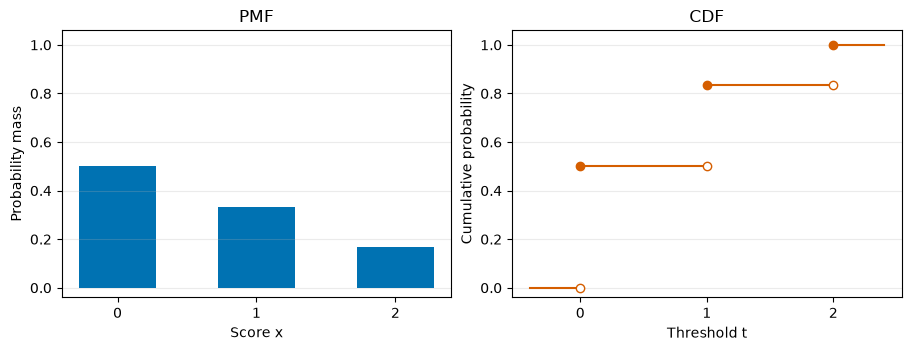

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), layout="constrained")
axes[0].bar(support, probabilities, width=0.55, color="#0072B2")
axes[0].set(xlabel="Score x", ylabel="Probability mass", title="PMF", xticks=support)
edges = np.array([-0.4, 0.0, 1.0, 2.0, 2.4])
heights = np.array([0.0, 0.5, 5 / 6, 1.0])
for left, right, height in zip(edges[:-1], edges[1:], heights):
    axes[1].plot([left, right], [height, height], color="#D55E00")
axes[1].scatter(
    support, heights[:-1], facecolors="white", edgecolors="#D55E00", zorder=3
)
axes[1].scatter(support, heights[1:], color="#D55E00", zorder=3)
axes[1].set(
    xlabel="Threshold t", ylabel="Cumulative probability", title="CDF", xticks=support
)
for ax in axes:
    ax.set_ylim(-0.04, 1.06)
    ax.grid(axis="y", alpha=0.25)
# 例如 t=1 时采用实心点 5/6，而不是空心点 1/2。
plt.show()

## 4 连续模型用密度的积分计算概率

本章讨论具有概率密度函数的连续随机变量。概率密度函数（probability density function，PDF）记为 $f_X(x)$，满足

$$f_X(x)\ge0,\qquad \int_{-\infty}^{\infty}f_X(x)\,dx=1,\qquad
P(a\le X\le b)=\int_a^b f_X(x)\,dx\quad(a\le b).$$

密度高度不是单点概率。这样的模型对任一单点都有 $P(X=a)=0$，所以区间端点取不取不影响概率；概率为零也不能简单理解为逻辑上不可能取到这个数。

例如在 [0,0.2] 上密度恒为 5，区间外为 0，总面积为 1。密度 5 大于 1 仍然合法；[0.05,0.10] 的概率为 $5\times0.05=0.25$。若 X 的单位为秒，密度单位就是每秒，积分后的概率无单位。

In [5]:
density = 5.0
print("总面积：", density * 0.2)  # 1。
print("区间概率：", density * (0.10 - 0.05))  # 0.25。
print("单点的积分：", density * (0.10 - 0.10))  # 0，不能用密度 5 替代。

总面积： 1.0
区间概率： 0.25
单点的积分： 0.0


### 4.1 从归一化求常数，再求 CDF

设 $f_X(x)=cx$ 在 $0\le x\le1$ 上成立，区间外密度为零。c 为待定非负常数。由 $\int_0^1cx\,dx=c/2=1$ 得到 c=2。于是

$$F_X(t)=\begin{cases}0,&t<0,\\t^2,&0\le t\le1,\\1,&t>1.\end{cases}$$

一般地，具有密度时 $F_X(t)=\int_{-\infty}^t f_X(x)\,dx$；在密度连续的点，CDF 的导数等于密度。下面用解析积分值与 SciPy 求积相互核对，quad 返回的第二个数是估计绝对误差，不是真实误差的精确值。

In [6]:
total, estimated_error = quad(lambda x: 2 * x, 0, 1)
interval, _ = quad(lambda x: 2 * x, 0.25, 0.75)
print("总积分与估计误差：", total, estimated_error)  # 预期密度总积分接近 1；本次积分器给出的误差估计约 1.1e-14。
print("区间积分：", interval)  # 0.5。
print("由 CDF 相减：", 0.75**2 - 0.25**2)  # 0.5。
print("总积分与解析值之差：", abs(total - 1))  # 预期接近 0；本次计算为 0。

总积分与估计误差： 1.0 1.1102230246251565e-14
区间积分： 0.5
由 CDF 相减： 0.5
总积分与解析值之差： 0.0


## 5 分位数反过来寻找概率阈值

给定 $0<q<1$，分位数（quantile）寻找累计概率达到 q 的位置。对严格递增且连续的 CDF，可解 $F_X(t)=q$；例如上面的 $F_X(t)=t^2$ 在 [0,1] 上给出 $t=\sqrt q$。

离散 CDF 有跳跃，通常无法恰好等于 q。本章使用“使 CDF 至少为 q 的最小取值”这一约定。记分例子 q=0.6 时，分位数是 1，但 $F_X(1)=5/6$，并不是 0.6。

分位数描述模型分布的位置，不是从有限样本构造的参数置信区间。代码中的 ppf 是 SciPy 的分位数接口；离散 ppf 的 q=0 有特殊端点约定，本章只使用严格位于 0 与 1 之间的 q。

In [7]:
q = 0.6
discrete_quantile = support[np.flatnonzero(np.cumsum(probabilities) >= q)[0]]
continuous_quantile = np.sqrt(q)
print("记分分位数及其 CDF：", discrete_quantile, score_cdf(discrete_quantile))  # 预期约为 1 0.833333。
print("连续分位数及其 CDF：", continuous_quantile, continuous_quantile**2)  # 预期约为 0.774597 0.6。
# 一个对应跳跃后的 5/6，另一个回代为 0.6；不是同一种反函数情况。

记分分位数及其 CDF： 1 0.8333333333333333
连续分位数及其 CDF： 0.7745966692414834 0.6000000000000001


## 6 分布参数与计算接口

一个分布族用参数描述多个具体分布，例如“二项分布”还需要试验次数与单次概率才能计算。记号 $X\sim D$ 表示 X 服从分布 D。参数的取值条件、支持范围与实际模型假设需要一起指定。

SciPy 的分布对象提供以下接口。把参数固定为一个对象后，各方法都会使用同一组参数，便于比较。

| 名称 | 中文名称／含义 | 返回什么 |
| --- | --- | --- |
| pmf | 概率质量函数 | 离散取值的单点概率 |
| pdf | 概率密度函数 | 连续模型的密度高度 |
| cdf | 累计分布函数 | 不大于输入阈值的概率 |
| sf | 右尾概率函数 | 大于输入阈值的概率 |
| ppf | 分位数函数 | 给定累计概率对应的位置 |
| rvs | 随机样本生成 | 从指定模型模拟出的值 |

下面先只指定一个 Bernoulli 分布并查询两点概率，随后说明它的数学含义。

In [8]:
binary_model = stats.bernoulli(p=0.3)
print("0、1 的质量：", binary_model.pmf([0, 1]))  # [0.7, 0.3]。
print("不超过 0 的概率：", binary_model.cdf(0))  # 0.7。
print("大于 0 的概率：", binary_model.sf(0))  # 0.3。

0、1 的质量： [0.7 0.3]
不超过 0 的概率： 0.7
大于 0 的概率： 0.3


## 7 Bernoulli 分布描述一次二元结果

伯努利分布（Bernoulli distribution）用 $B\sim\operatorname{Bernoulli}(p)$ 表示，参数 $0\le p\le1$，取值为 0 或 1，且

$$P(B=1)=p,\qquad P(B=0)=1-p.$$

“1”只是预先约定的事件发生，例如一次模拟任务是否通过；“0”表示未发生。p=0 或 p=1 时退化为固定结果。一次 Bernoulli 描述单个结果，本身不包含多次试验之间的独立性保证。

下面按独立重复模型采样，使用局部 Generator 和固定种子。相同环境、种子与调用顺序便于重复本次观察；不承诺跨版本、改变调用顺序后仍逐项相同。有限样本的频率不要求精确等于参数 p。

In [9]:
rng = np.random.default_rng(20260916)
binary_samples = binary_model.rvs(size=12, random_state=rng)
print("12 次模拟结果：", binary_samples)  # 本次固定种子下为 [0 0 0 0 0 0 0 0 0 0 0 0]。
print("本次 1 的频率：", np.mean(binary_samples == 1))  # 本次 12 次模拟中未出现 1，频率为 0；这不改变模型参数 p=0.3。
print("p=0 的质量：", stats.bernoulli.pmf([0, 1], p=0))  # p=0 时理论质量为 [1, 0]，与随机种子无关。
print("p=1 的质量：", stats.bernoulli.pmf([0, 1], p=1))  # p=1 时理论质量为 [0, 1]，与随机种子无关。
# 前两行是本次样本观察；最后两行核对退化模型，不由小样本频率估计它们。
# 此环境与种子下，12 次结果恰好全为 0；这不能说明生成参数 p=0。

12 次模拟结果： [0 0 0 0 0 0 0 0 0 0 0 0]
本次 1 的频率： 0.0
p=0 的质量： [1. 0.]
p=1 的质量： [0. 1.]


## 8 二项分布数固定次数中的成功次数

若 $B_1,\ldots,B_n$ 相互独立且都服从 Bernoulli(p)，n 为正整数，令 $K=\sum_{i=1}^n B_i$，则 $K\sim\operatorname{Binomial}(n,p)$。

恰好 k 次成功的一种指定排列，其概率为 $p^k(1-p)^{n-k}$；成功位置有 $\binom nk=n!/[k!(n-k)!]$ 种选择。因此

$$P(K=k)=\binom nk p^k(1-p)^{n-k},\qquad k=0,1,\ldots,n.$$

参数满足 $0\le p\le1$；p=0、1 时分别集中于 0、n。n=0 的约定情形也集中于 0。不能把概率各不相同或彼此相关的二元结果，直接按同一个二项分布计算。

例如 n=5、p=0.3，恰有两次成功的概率为 $10\times0.3^2\times0.7^3=0.3087$。至少两次是 $P(K>1)$，对应 sf(1)，并非 sf(2)。

In [10]:
n, p = 5, 0.3
count_model = stats.binom(n=n, p=p)
counts = np.arange(n + 1)
mass = count_model.pmf(counts)
manual = comb(n, 2) * p**2 * (1 - p) ** (n - 2)
print("手算与 SciPy 的 P(K=2)：", manual, count_model.pmf(2))  # 预期约为 0.3087 0.3087。
print("完整 PMF 与总和：", mass, mass.sum())  # 预期约为 [0.16807 0.36015 0.3087 0.1323 0.02835 0.00243] 1。
print("P(K≥2) 的求和与右尾：", mass[2:].sum(), count_model.sf(1))  # 预期约为 0.47178 0.47178。
# 预期约为 [0.7 0.3] [0.7 0.3]。
print(
    "n=1 与 Bernoulli 一致：", stats.binom.pmf([0, 1], 1, p), binary_model.pmf([0, 1])
)
# PMF 归一化来自二项式展开 (p + 1 - p)^n=1；这里是数值核对。

手算与 SciPy 的 P(K=2)： 0.3086999999999999 0.3086999999999998
完整 PMF 与总和： [0.16807 0.36015 0.3087  0.1323  0.02835 0.00243] 0.9999999999999996
P(K≥2) 的求和与右尾： 0.4717799999999997 0.47178
n=1 与 Bernoulli 一致： [0.7 0.3] [0.7 0.3]


### 8.1 比较完整分布与模拟频率

每个模拟样本是一组 5 次独立试验的成功数，重复 10000 组。柱高是样本中各计数出现的比例，圆点是模型的 PMF；它们采用相同的概率刻度。这样的图只观察该生成模型的有限样本表现，不检验真实任务是否满足独立、同概率条件。

各取值频率： [0.1694 0.3618 0.3089 0.1322 0.0257 0.002 ]
频率与理论质量的最大绝对差： 0.0026499999999999857


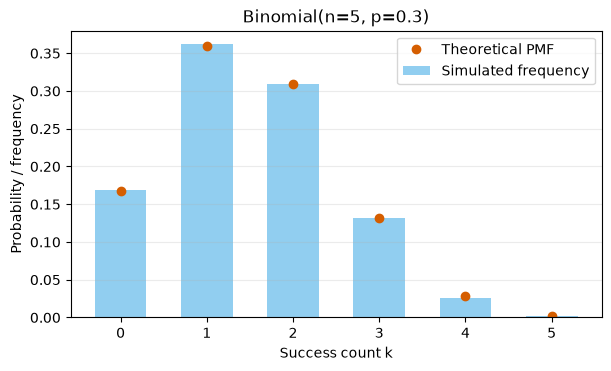

In [11]:
count_rng = np.random.default_rng(1608)
# 从已定义的二项模型抽样；bincount 按成功次数统计，再除以总样本数。
count_samples = count_model.rvs(size=10000, random_state=count_rng)
frequencies = np.bincount(count_samples, minlength=n + 1) / count_samples.size
print("各取值频率：", frequencies)  # 本次固定种子下约为 [0.1694 0.3618 0.3089 0.1322 0.0257 0.002 ]。
print("频率与理论质量的最大绝对差：", np.max(abs(frequencies - mass)))  # 本次固定种子下，频率与理论质量的最大差约 0.00265；有限样本不会逐项完全相等。
# 柱形表示本次频率，圆点表示模型 PMF，二者在同一离散取值上比较。
fig, ax = plt.subplots(figsize=(6, 3.6), layout="constrained")
ax.bar(
    counts,
    frequencies,
    width=0.6,
    color="#56B4E9",
    alpha=0.65,
    label="Simulated frequency",
)
ax.plot(counts, mass, "o", color="#D55E00", label="Theoretical PMF")
ax.set(
    xlabel="Success count k",
    ylabel="Probability / frequency",
    title="Binomial(n=5, p=0.3)",
    xticks=counts,
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
# 本次柱高靠近理论 PMF 圆点，k=1、2 的柱最高；各柱与圆点仍有抽样差异。
plt.show()

## 9 分类分布描述一次多类别结果

分类分布（categorical distribution，也称 multinoulli distribution）描述一次从有限个类别中选一个的结果。设共有 m 个类别，m 为正整数，概率向量为 $(p_1,\ldots,p_m)$，要求每个 $p_i\ge0$ 且 $\sum_{i=1}^m p_i=1$。

可用整数 0 到 m−1 编码类别，但编号大小不自动表示类别之间的大小或距离。分类分布描述一次的类别；多次独立分类结果的各类计数所构成的向量是另一个对象，不能把一次类别编号与计数向量混淆。

下面用人工设定的 A、B、C 三类和概率 0.2、0.5、0.3，通过 Generator.choice 采样；p 的顺序必须与类别数组一致。

In [12]:
categories = np.array(["A", "B", "C"])
category_probabilities = np.array([0.2, 0.5, 0.3])
category_rng = np.random.default_rng(1609)
category_samples = category_rng.choice(categories, size=6000, p=category_probabilities)
print("概率归一化：", category_probabilities.sum())  # 给定的三个类别概率之和为 1。
for label, probability in zip(categories, category_probabilities):
    frequency = np.mean(category_samples == label)
    # 本次三类频率约为 0.197、0.505、0.297；理论概率分别为 0.2、0.5、0.3。
    print(f"类别 {label}：模型概率={probability:.3f}，本次频率={frequency:.3f}")
# 重命名类别不会改变对应概率；更改顺序时必须同步重排概率向量。

概率归一化： 1.0
类别 A：模型概率=0.200，本次频率=0.197
类别 B：模型概率=0.500，本次频率=0.505
类别 C：模型概率=0.300，本次频率=0.297


## 10 均匀分布在等长区间中分配相同概率

连续均匀分布 $U\sim\operatorname{Uniform}(a,b)$ 的参数 a、b 为实数且 a<b，密度在 [a,b] 内为 $1/(b-a)$，区间外为 0。其 CDF 为

$$F_U(t)=\begin{cases}0,&t<a,\\(t-a)/(b-a),&a\le t\le b,\\1,&t>b.\end{cases}$$

在 [a,b] 内等长的子区间有相同概率。这里相等的是密度与等长区间概率，不是每个单点分到一个正概率。

SciPy 的 uniform 使用 loc=a、scale=b−a，第二个参数是宽度，不是右端点。取 a=2、b=5 时，宽度为 3；例如 [2.5,3.5] 的概率为 1/3。

In [13]:
left, right = 2.0, 5.0
uniform_model = stats.uniform(loc=left, scale=right - left)
print("支持范围：", uniform_model.support())  # (2, 5)。
print("区间内密度：", uniform_model.pdf(3.0))  # 1/3。
print("区间概率：", uniform_model.cdf(3.5) - uniform_model.cdf(2.5))  # 1/3。
print("0.8 分位数：", uniform_model.ppf(0.8))  # 2 + 0.8×3 = 4.4。
integral, _ = quad(uniform_model.pdf, left, right)
print("密度总积分：", integral)  # 接近 1。

支持范围： (np.float64(2.0), np.float64(5.0))
区间内密度： 0.3333333333333333
区间概率： 0.33333333333333337
0.8 分位数： 4.4
密度总积分： 1.0


## 11 正态分布区分位置与标准差

正态分布（normal distribution，也称 Gaussian distribution）记为 $X\sim N(\mu,\sigma^2)$，$\mu\in\mathbb R$、$\sigma>0$。密度为

$$f_X(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),\qquad x\in\mathbb R.$$

μ 是总体均值，决定曲线中心；σ 是总体标准差，决定围绕均值的伸展尺度，$\sigma^2$ 是方差。本章先用这两个参数描述曲线。数学记号 N 的第二个位置写方差，SciPy 的 scale 则接收标准差 σ，不能直接填 $\sigma^2$。

标准化变量 $Z=(X-\mu)/\sigma$ 服从 N(0,1)，其 CDF 记作 Φ。因此 $P(a<X\le b)=\Phi((b-\mu)/\sigma)-\Phi((a-\mu)/\sigma)$。正态模型支持所有实数，若变量必须非负，使用它之前还须检查负值概率是否符合问题。

In [14]:
mu, sigma = 10.0, 2.0
normal_model = stats.norm(loc=mu, scale=sigma)
interval_probability = normal_model.cdf(12) - normal_model.cdf(8)
standardized = stats.norm.cdf((12 - mu) / sigma) - stats.norm.cdf((8 - mu) / sigma)
print("8 到 12 的概率及标准化计算：", interval_probability, standardized)  # 预期约为 0.682689 0.682689。
# 理论均值、标准差、方差分别为 10、2、4。
print(
    "均值、标准差、方差：", normal_model.mean(), normal_model.std(), normal_model.var()
)
print("0.975 分位数：", normal_model.ppf(0.975))  # 约 13.9199。
print("低于 0 的模型概率：", normal_model.cdf(0))  # 约 2.8665e-7，很小但不是数学上的零。
total, estimated_error = quad(normal_model.pdf, -np.inf, np.inf)
print("密度总积分与求积误差估计：", total, estimated_error)  # 预期密度总积分接近 1；本次求积误差估计约 6.4e-9。

8 到 12 的概率及标准化计算： 0.6826894921370859 0.6826894921370859
均值、标准差、方差： 10.0 2.0 4.0
0.975 分位数： 13.919927969080108
低于 0 的模型概率： 2.866515718791933e-07
密度总积分与求积误差估计： 1.0 6.412963913145714e-09


### 11.1 改变参数，观察曲线的平移与伸展

下面比较三个已指定的正态密度。保持 σ 相同而改变 μ，曲线平移；保持 μ 相同而增加 σ，曲线更宽，峰值更低，但整个实数轴上的积分仍为 1。

曲线形状相似不意味着某组真实数据就来自正态分布。这里的曲线直接由模型计算，没有进行分布拟合。

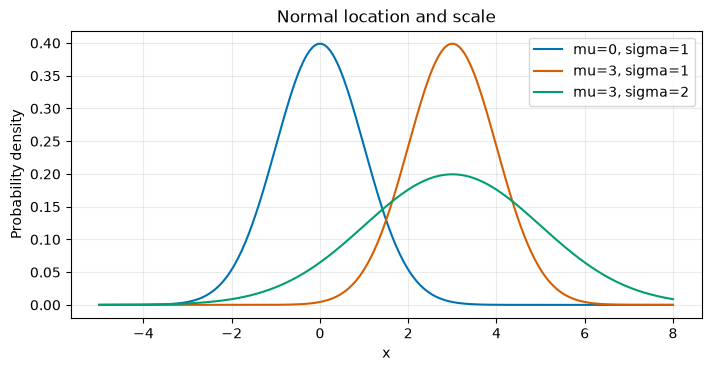

In [15]:
x = np.linspace(-5, 8, 500)
fig, ax = plt.subplots(figsize=(7, 3.6), layout="constrained")
for location, scale, color in [(0, 1, "#0072B2"), (3, 1, "#D55E00"), (3, 2, "#009E73")]:
    ax.plot(
        x,
        stats.norm.pdf(x, loc=location, scale=scale),
        color=color,
        label=f"mu={location}, sigma={scale}",
    )
ax.set(xlabel="x", ylabel="Probability density", title="Normal location and scale")
ax.legend()
ax.grid(alpha=0.25)
# 图只显示有限区间；正态分布的尾部延伸到整个实数轴。
# 预期均值改变时峰位置平移；标准差更大时曲线更宽、峰更低。
plt.show()

## 12 指数分布明确率与尺度的倒数关系

指数分布 $T\sim\operatorname{Exponential}(\lambda)$ 的率参数 $\lambda>0$，取值范围为 $t\ge0$，密度与 CDF 为

$$f_T(t)=\lambda e^{-\lambda t},\qquad F_T(t)=1-e^{-\lambda t}\quad(t\ge0).$$

t<0 时二者都为零。密度积分为 $[-e^{-\lambda t}]_0^\infty=1$，右尾概率为 $P(T>t)=e^{-\lambda t}$。若 T 的单位为秒，λ 的单位为每秒，指数 $-\lambda t$ 无单位。

SciPy 的 expon 使用 scale=1/λ，loc=0 时对应上式。指数模型常用于特定机制下的等待时间；等待时间非负只是必要形态，不能由此认定任何等待时间都服从指数分布。

In [16]:
rate = 0.5
waiting_model = stats.expon(loc=0, scale=1 / rate)
print("t=2 的密度：", waiting_model.pdf(2))  # 0.5×exp(-1)。
print("两秒内的概率：", waiting_model.cdf(2))  # 约 0.6321。
print("超过两秒的概率：", waiting_model.sf(2))  # exp(-1)，约 0.3679。
print("两种右尾计算：", waiting_model.sf(2), np.exp(-rate * 2))  # 预期约为 0.367879 0.367879。
print("密度总积分：", quad(waiting_model.pdf, 0, np.inf)[0])  # 预期约为 1。

t=2 的密度： 0.18393972058572117
两秒内的概率： 0.6321205588285577
超过两秒的概率： 0.36787944117144233
两种右尾计算： 0.36787944117144233 0.36787944117144233
密度总积分： 1.0


### 12.1 无记忆性是一条模型性质

指数分布具有无记忆性（memorylessness）。给定 s、t≥0，条件事件 T>s 的概率为正，有

$$P(T>s+t\mid T>s)=\frac{P(T>s+t)}{P(T>s)}
=\frac{e^{-\lambda(s+t)}}{e^{-\lambda s}}=e^{-\lambda t}=P(T>t).$$

这表示已等待 s 之后，剩余等待时间的分布不随 s 改变。它是一条明确且较强的假设；有固定时刻表的等待机制通常不能直接按这个性质处理。

In [17]:
s, t = 3.0, 2.0
conditional_tail = waiting_model.sf(s + t) / waiting_model.sf(s)
fresh_tail = waiting_model.sf(t)
print("已经等 3 秒后，再等超过 2 秒的条件概率：", conditional_tail)  # 预期约为 0.367879。
print("从开始就要等超过 2 秒的概率：", fresh_tail)  # 预期约为 0.367879。
# 当前参数下两者都为 exp(-1)；相等来自上面的代数式。

已经等 3 秒后，再等超过 2 秒的条件概率： 0.36787944117144233
从开始就要等超过 2 秒的概率： 0.36787944117144233


## 13 综合应用：检查模拟等待时间的区间与分位数

继续采用 λ=0.5 每秒的指数教学模型，独立模拟 5000 次等待。模型完全由我们指定，不代表实测系统。设想用一个阈值覆盖模型中 90% 的等待时间，解

$$1-e^{-\lambda t_{0.9}}=0.9
\quad\Longrightarrow\quad t_{0.9}=-\frac{\ln(0.1)}\lambda.$$

先用解析式与 ppf 核对阈值，再观察本次样本落在阈值内的比例。模型分位数、由样本计算的分位数和阈值内的样本比例是三个不同的量。

In [18]:
waiting_rng = np.random.default_rng(1613)
waiting_samples = waiting_model.rvs(size=5000, random_state=waiting_rng)
threshold = -np.log(0.1) / rate
sample_fraction = np.mean(waiting_samples <= threshold)
sample_quantile = np.quantile(waiting_samples, 0.9, method="linear")
print("解析与 ppf 的 90% 阈值（秒）：", threshold, waiting_model.ppf(0.9))  # 预期约为 4.60517 4.60517。
print("模型在此阈值处的累计概率：", waiting_model.cdf(threshold))  # 0.9。
print("本次样本在阈值内的比例：", sample_fraction)  # 本次固定种子下约为 0.9008。
print("本次样本的 90% 分位数（秒）：", sample_quantile)  # 本次固定种子下约为 4.59233。
print("1 到 3 秒的理论概率：", waiting_model.cdf(3) - waiting_model.cdf(1))  # 预期约为 0.3834。
# 本次固定种子下约为 0.3956。
print(
    "1 到 3 秒的本次样本比例：",
    np.mean((waiting_samples >= 1) & (waiting_samples <= 3)),
)
# 样本量、种子与模型均已指定；有限样本结果不要求恰好等于理论值。

解析与 ppf 的 90% 阈值（秒）： 4.605170185988091 4.605170185988092
模型在此阈值处的累计概率： 0.9
本次样本在阈值内的比例： 0.9008
本次样本的 90% 分位数（秒）： 4.592327025354966
1 到 3 秒的理论概率： 0.38340049956420363
1 到 3 秒的本次样本比例： 0.3956


### 13.1 直方图与累计频率各检查什么

左图的密度直方图用“该箱频数 ÷ 总样本数 ÷ 箱宽”计算高度，所有柱形面积之和为 1，不能直接将柱高当概率。箱边界覆盖全部样本，避免截去样本后重新归一化。

右图的经验累计分布在每个阈值处表示“不大于它的样本比例”，是用排序值和累计比例画出的阶梯。与模型 CDF 接近只说明这批模拟样本的表现；它不能反过来证明真实等待机制是指数分布。虚线标出模型 90% 阈值，横轴单位为秒。

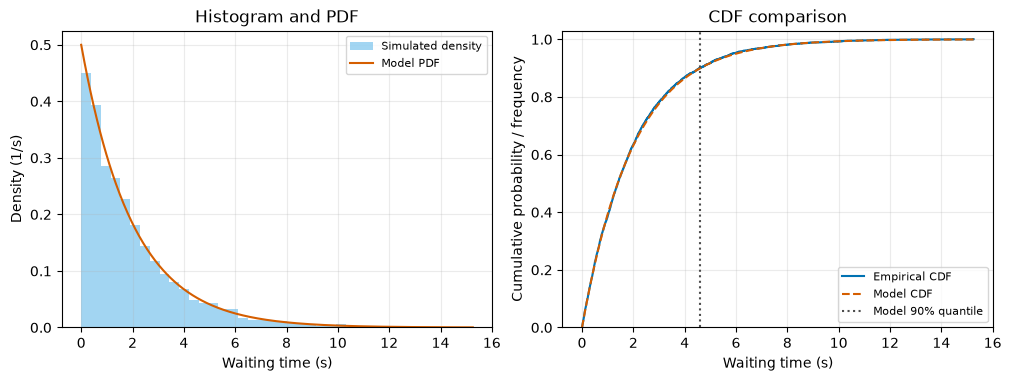

直方图柱形总面积： 1.0
图示范围以外的模型右尾概率： 0.00048585589219178013


In [19]:
# 直方图与理论 PDF 共用区间；排序后的样本用于构造累计频率。
maximum = waiting_samples.max()
bins = np.linspace(0, maximum, 41)
x = np.linspace(0, maximum, 500)
ordered_samples = np.sort(waiting_samples)
empirical_probabilities = np.arange(1, waiting_samples.size + 1) / waiting_samples.size
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), layout="constrained")
heights, bin_edges, _ = axes[0].hist(
    waiting_samples,
    bins=bins,
    density=True,
    alpha=0.55,
    color="#56B4E9",
    label="Simulated density",
)
axes[0].plot(x, waiting_model.pdf(x), color="#D55E00", label="Model PDF")
axes[0].set(
    xlabel="Waiting time (s)", ylabel="Density (1/s)", title="Histogram and PDF"
)
# 每到一个样本位置累计增加 1/n；post 让阶梯保持到下一个位置。
axes[1].step(
    np.r_[0, ordered_samples],
    np.r_[0, empirical_probabilities],
    where="post",
    color="#0072B2",
    label="Empirical CDF",
)
axes[1].plot(x, waiting_model.cdf(x), "--", color="#D55E00", label="Model CDF")
axes[1].axvline(threshold, linestyle=":", color="0.3", label="Model 90% quantile")
axes[1].set(
    xlabel="Waiting time (s)",
    ylabel="Cumulative probability / frequency",
    title="CDF comparison",
    ylim=(0, 1.03),
)
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
# 本次左图密度从零附近向右递减；右图经验 CDF 靠近模型线，在约 4.605 s 处达到 0.9 附近。
plt.show()
# 密度高度乘分箱宽度才得到面积，样本最大值外仍可能有模型尾部。
print("直方图柱形总面积：", np.sum(heights * np.diff(bin_edges)))  # 本次固定种子下约为 1。
print("图示范围以外的模型右尾概率：", waiting_model.sf(maximum))  # 本次固定种子下约为 0.000485856。
# 直方图覆盖了全部样本，但有限最大样本值之外，模型仍有非零尾部概率。

## 本章小结

（1）随机变量把随机结果映射成数值，分布描述这些数值的概率。离散模型用 PMF 求和，具有密度的连续模型用 PDF 积分；密度高度不是单点概率。

（2）CDF 表示不大于阈值的概率。离散端点是否包含会改变结果；离散分位数通常位于 CDF 跳跃处，不要求回代恰好等于目标概率。

（3）Bernoulli 描述一次二元结果，二项分布计数固定次数独立同概率试验的成功数，分类分布描述一次类别选择。连续均匀、正态和指数模型各有参数、支持范围与条件。

（4）库参数要与数学记号对应：uniform 的 scale 是宽度，norm 的 scale 是标准差，expon 的 scale 是率的倒数。固定种子帮助重复模拟，有限样本与理论分布仍然不同。

自查：为什么密度可以大于 1？为什么至少两次成功要用 sf(1)？为什么等待时间非负还不足以采用指数模型？

## 练习

（1）设离散变量取值为 −1、1、3，对应概率为 0.2、0.5、0.3。写出其分段 CDF，分别求 $P(-1<X\le1)$、$P(-1\le X\le1)$ 与 0.6 分位数。用求和核对端点，并画出实心、空心端点位置。

In [20]:
exercise_values = np.array([-1, 1, 3])
exercise_probabilities = np.array([0.2, 0.5, 0.3])
# 补充：CDF、两种区间概率和分位数；说明为什么两个区间答案不同。

（2）连续密度在 [0,2] 内为 $f(x)=cx$，区间外为 0。由归一化求 c，写出完整 CDF 和 0.75 分位数，用积分核对 $P(0.5<X<1.5)$。说明 f(1) 为什么不是 $P(X=1)$。

In [21]:
lower, upper = 0.0, 2.0
# 补充：先手算归一化与 CDF，再用 quad 核对区间概率。

（3）两次独立试验的成功概率分别是 0.2 和 0.8。枚举 00、01、10、11 四种结果，得到总成功数 K 的 PMF，再与 Binomial(2,0.5) 比较。两次概率平均为 0.5，是否足以套二项分布？指出改变了哪一条生成条件。

In [22]:
p_first, p_second = 0.2, 0.8
comparison_model = stats.binom(n=2, p=0.5)
# 补充：按独立性求四种结果概率、合并计数，再比较三个计数的质量。

（4）用指数模型描述等待时间，要求至少 95% 不超过 6 秒。由 $1-e^{-6\lambda}\ge0.95$ 求 λ 的范围，并用正确的 scale 检查边界值。固定种子模拟 5000 次，比较样本比例与 0.95；再解释如果等待机制有固定时刻表，为什么不能仅靠调 λ 修复模型假设。

In [23]:
deadline = 6.0
required_probability = 0.95
exercise_rng = np.random.default_rng(1614)
# 补充：解析率范围、scale、CDF 核对和模拟比例，分别陈述理论保证与样本观察。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：独立允许把两次结果的概率相乘，却不保证成功概率相同。

提示 2：把四种有序结果合并为成功次数 0、1、2 后再比较。

### 练习（3）参考解析

00、01、10、11 的概率依次为 $0.8\times0.2=0.16$、$0.8\times0.8=0.64$、$0.2\times0.2=0.04$、$0.2\times0.8=0.16$。因此 K 的概率质量为 $(0.16,0.68,0.16)$。

Binomial(2,0.5) 的质量为 $(0.25,0.50,0.25)$。两者均值都是 1，但分布不同：二项计数还要求每次试验有同一个成功概率。只用平均成功概率替换两个不同参数，会改变模型。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | Jeremy Orloff、Jonathan Bloom，18.05 Spring 2022：[Reading 4a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class04-prep-a.pdf)，§2.2–2.8、第 2–6 页，随机变量映射、PMF、CDF 及端点；§3.1–3.2、第 6–8 页，Bernoulli 与独立同概率二项计数；[Reading 5b](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class05-prep-b.pdf)，§4–4.3、第 2–6 页，密度、积分归一化、零单点概率与 CDF；[Reading 5c](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class05-prep-c.pdf)，§3–5、第 1–7 页，连续均匀、指数、无记忆性与正态模型。 |
| Deep Learning 作者网站 | [Chapter 3 Probability and Information Theory](https://www.deeplearningbook.org/contents/prob.html)，§3.3.1–3.3.2 的归一化与密度/质量区别；§3.9.2 的 Categorical/Multinoulli、类别标签与多次计数的区别；§3.9.3 的正态参数范围。 |
| SciPy 官方文档 | SciPy 1.18：[bernoulli](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html)、[binom](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html) 的 Notes 与 PMF 参数；[uniform](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.uniform.html)、[norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)、[expon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html) 的 loc/scale 与 Methods；[rv_discrete.ppf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.ppf.html) 的 Notes，离散分位数最小取值约定及 q=0 例外；[rv_continuous.rvs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.rvs.html)，Generator 作为 random_state；[quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html)，积分边界、无穷区间与误差估计返回值。 |
| NumPy 官方文档 | NumPy 2.5：[Random Generator](https://numpy.org/doc/stable/reference/random/generator.html)，default_rng、seed、No Compatibility Guarantee；[Generator.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)，p 的逐项对应、归一化与有放回采样；[quantile](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html)，method="linear" 的样本分位数插值约定。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)，bins、density 和 range：柱高与箱宽、截断样本后的归一化；[Axes.step](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.step.html)，where="post" 对应从当前 x 延伸到右侧区间的阶梯。 |